## Bank of Abyssinia Review Analysis

Import Required Libraries

In [43]:
import sys
import os

sys.path.insert(0, os.path.abspath('C:/Users/dagic/OneDrive/Documents/KAIM/Week_2/fintech-review-analytics'))

print('Path set. Python will now look in:', os.path.abspath('C:/Users/dagic/OneDrive/Documents/KAIM/Week_2/fintech-review-analytics'))

Path set. Python will now look in: C:\Users\dagic\OneDrive\Documents\KAIM\Week_2\fintech-review-analytics


In [44]:
# Core libraries
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns

import nltk
from nltk.sentiment import SentimentIntensityAnalyzer
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk import word_tokenize, pos_tag
from textblob import TextBlob
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer

from collections import Counter
from wordcloud import WordCloud
from datetime import datetime
from google_play_scraper import app, reviews, Sort

# Download necessary NLTK components
for res in ['vader_lexicon', 'stopwords', 'averaged_perceptron_tagger', 'punkt', 'wordnet']:
    nltk.download(res, quiet=True)

sia = SentimentIntensityAnalyzer()
stop_words = set(stopwords.words('english'))

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (11, 5)
print("Environment ready ✓")

from src.data_scrapper import scrape_metadata, scrape_reviews, data_quality_check
from src.data_preprocessor import missing_values, duplicate_reviews, check_dateFormat, missing_values, normalize_date, clean_text, invalid_reviews, remove_duplicates, save_cleaned_data, preprocessing_report
from src.modular_nlp_pipeline import modular_nlp_pipeline

print("Libraries loaded successfully!")

Environment ready ✓
Libraries loaded successfully!


[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\dagic\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\dagic\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\dagic\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


Defining Variables

In [45]:
App_Id = "com.boa.boaMobileBanking"
bank = 'Bank of Abyssinia'
source = 'Google Play Store'
print(f" Scraping Review for Bank: {bank} with App ID: {App_Id} from Source: {source}")


 Scraping Review for Bank: Bank of Abyssinia with App ID: com.boa.boaMobileBanking from Source: Google Play Store


## Mobile App Review Data Scraping from Google Play Store

In [46]:
# Get meta data for the app
scrape_metadata(App_Id, bank)

App Info for Bank of Abyssinia
App Title   : BoA Mobile
Current Score: 4.391073
Total Ratings: 9,254
Total Reviews: 1,461
Installs     : 1,000,000+


{'title': 'BoA Mobile',
 'description': 'BoA Mobile an innovative app from Bank of Abyssinia, empowers customers to effortlessly conduct a wide range of banking transactions right at their fingertips. Experience seamless and convenient banking on the go with BoA Mobile',
 'descriptionHTML': 'BoA Mobile an innovative app from Bank of Abyssinia, empowers customers to effortlessly conduct a wide range of banking transactions right at their fingertips. Experience seamless and convenient banking on the go with BoA Mobile',
 'summary': 'Mobile Banking Application',
 'installs': '1,000,000+',
 'minInstalls': 1000000,
 'realInstalls': 2390418,
 'score': 4.391073,
 'ratings': 9254,
 'reviews': 1461,
 'histogram': [806, 304, 383, 727, 7031],
 'price': 0,
 'free': True,
 'currency': 'USD',
 'sale': False,
 'saleTime': None,
 'originalPrice': None,
 'saleText': None,
 'offersIAP': False,
 'inAppProductPrice': None,
 'developer': 'Bank of Abyssinia',
 'developerId': '7216950951017247612',
 'develop

In [47]:
#scrape 500 reviews for the app
df_reviews, continuation_token = scrape_reviews(App_Id, bank, count=500)
df_reviews = pd.DataFrame(df_reviews)

Collected 500 raw reviews for Bank of Abyssinia app.


In [48]:
print(type(df_reviews))

<class 'pandas.DataFrame'>


In [49]:
print(df_reviews.head())
print(df_reviews.columns)

                               reviewId          userName  \
0  9dd3879e-2b0c-4058-8c8c-19f6b376f69c      Abel Legesse   
1  5f69466d-ec06-4eb5-816c-296accffeff2        Wende Rege   
2  f9246b8a-6688-4249-b804-0b0c5dd60590        hamza Bedr   
3  21bcff26-5b05-485d-958f-4832ec1fac01     Tsegay Teklay   
4  c5eb7589-59b7-4d72-8aa9-100a703ecaa3  shambel mulugeta   

                                           userImage  \
0  https://play-lh.googleusercontent.com/a-/ALV-U...   
1  https://play-lh.googleusercontent.com/a-/ALV-U...   
2  https://play-lh.googleusercontent.com/a/ACg8oc...   
3  https://play-lh.googleusercontent.com/a/ACg8oc...   
4  https://play-lh.googleusercontent.com/a-/ALV-U...   

                                             content  score  thumbsUpCount  \
0  The worst app, also bank am begging for my own...      1              0   
1                                         was Good 🙏      5              0   
2                                               cool      5   

In [50]:
# Inspect what a single raw review looks like

print("Keys in a single review:")
print(list(df_reviews.iloc[0].keys()))

print("\nFirst raw review (sample):")
for key, value in df_reviews.iloc[0].items():
    print(f"  {key}: {value}")

Keys in a single review:
['reviewId', 'userName', 'userImage', 'content', 'score', 'thumbsUpCount', 'reviewCreatedVersion', 'at', 'replyContent', 'repliedAt', 'appVersion']

First raw review (sample):
  reviewId: 9dd3879e-2b0c-4058-8c8c-19f6b376f69c
  userName: Abel Legesse
  userImage: https://play-lh.googleusercontent.com/a-/ALV-UjVlAiPqwEucytjQHmhCbqlROOv44ryrgg5M6NZ2fb1qyojQN2u1
  content: The worst app, also bank am begging for my own money
  score: 1
  thumbsUpCount: 0
  reviewCreatedVersion: 26.05.11
  at: 2026-05-16 05:35:22
  replyContent: None
  repliedAt: None
  appVersion: 26.05.11


In [51]:
# Step 3: Extract only the columns we need
raw_data = []

for r in df_reviews.itertuples():
    raw_data.append({
        'review_id': r.reviewId,
        'review'   : r.content,
        'rating'   : r.score,
        'date'     : r.at,
        'bank'     : bank,
        'source'   : 'Google Play'
    })

# Build a DataFrame
df_raw = pd.DataFrame(raw_data)

print(f"Shape: {df_raw.shape}")
df_raw.head()

Shape: (500, 6)


,review_id,review,rating,date,bank,source
0,9dd3879e-2b0c-4058-8c8c-19f6b376f69c,"The worst app, also bank am begging for my own...",1,2026-05-16 05:35:22,Bank of Abyssinia,Google Play
1,5f69466d-ec06-4eb5-816c-296accffeff2,was Good 🙏,5,2026-05-15 17:10:06,Bank of Abyssinia,Google Play
2,f9246b8a-6688-4249-b804-0b0c5dd60590,cool,5,2026-05-15 14:07:21,Bank of Abyssinia,Google Play
3,21bcff26-5b05-485d-958f-4832ec1fac01,Its Good,5,2026-05-15 08:01:09,Bank of Abyssinia,Google Play
4,c5eb7589-59b7-4d72-8aa9-100a703ecaa3,good,5,2026-05-14 14:18:44,Bank of Abyssinia,Google Play


## Exploring the Raw Data

In [52]:
# Basic shape and types
print(f"Total reviews collected: {len(df_raw)}")
print(f"\nColumn dtypes:")
print(df_raw.dtypes)

Total reviews collected: 500

Column dtypes:
review_id               str
review                  str
rating                int64
date         datetime64[us]
bank                    str
source                  str
dtype: object


In [53]:
print("Rating Distribution:")
rating_counts = df_raw['rating'].value_counts().sort_index(ascending=False)
for rating, count in rating_counts.items():
    bar = '█' * (count // 4) 
    print(f"{rating} stars: {bar} ({count} reviews)")


Rating Distribution:
5 stars: ██████████████████████████████████████████████████████████████████████ (280 reviews)
4 stars: █████████ (37 reviews)
3 stars: ████ (18 reviews)
2 stars: ████ (16 reviews)
1 stars: █████████████████████████████████████ (149 reviews)


In [54]:
# What does the date column look like right now?
print("Sample date values (raw):")
print(df_raw['date'].head(10).to_string())

print(f"\nDate dtype: {df_raw['date'].dtype}")

Sample date values (raw):
0   2026-05-16 05:35:22
1   2026-05-15 17:10:06
2   2026-05-15 14:07:21
3   2026-05-15 08:01:09
4   2026-05-14 14:18:44
5   2026-05-12 04:50:32
6   2026-05-11 11:18:54
7   2026-05-09 07:41:50
8   2026-05-08 06:47:07
9   2026-05-07 03:33:06

Date dtype: datetime64[us]


## Data Quality Audit

In [55]:
data_quality_check(df_raw)

Data Quality Check:
------------------------------
Total reviews collected: 500
Missing values per column:
review_id    0
review       0
rating       0
date         0
bank         0
source       0
dtype: int64


In [56]:
missing_values(df_raw)

Removed 0 rows with missing critical data
Remaining: 500 reviews


,review_id,review,rating,date,bank,source
0,9dd3879e-2b0c-4058-8c8c-19f6b376f69c,"The worst app, also bank am begging for my own...",1,2026-05-16 05:35:22,Bank of Abyssinia,Google Play
1,5f69466d-ec06-4eb5-816c-296accffeff2,was Good 🙏,5,2026-05-15 17:10:06,Bank of Abyssinia,Google Play
2,f9246b8a-6688-4249-b804-0b0c5dd60590,cool,5,2026-05-15 14:07:21,Bank of Abyssinia,Google Play
3,21bcff26-5b05-485d-958f-4832ec1fac01,Its Good,5,2026-05-15 08:01:09,Bank of Abyssinia,Google Play
4,c5eb7589-59b7-4d72-8aa9-100a703ecaa3,good,5,2026-05-14 14:18:44,Bank of Abyssinia,Google Play
...,...,...,...,...,...,...
495,12f08f68-da19-4974-8086-304a40091d72,Very poor proformance,1,2025-03-01 15:02:44,Bank of Abyssinia,Google Play
496,b7206c5f-267e-44f1-b044-8f6f9392701d,It's not opening. Really frustrating,1,2025-03-01 09:18:34,Bank of Abyssinia,Google Play
497,d5e46c35-6bbf-4ce7-b184-cdc4c1e0eab1,Verry Amazing App from all IB,5,2025-03-01 03:35:08,Bank of Abyssinia,Google Play
498,99172a2f-926c-48be-a1b0-3971b984b6b2,Not working on this days,1,2025-02-26 05:29:28,Bank of Abyssinia,Google Play


Check for Duplicates

In [57]:
duplicate_reviews(df_raw)

Duplicate reviews:
------------------------------
Total duplicate review IDs: 0
Total duplicate review texts: 116
Total empty reviews: 0
Total duplicate reviews: 0


In [58]:
# Copying the raw DataFrame to work on a clean version
df = df_raw.copy()
print("Data copied for preprocessing.")

Data copied for preprocessing.


Remove Missing Data

In [59]:
df = missing_values(df)

Removed 0 rows with missing critical data
Remaining: 500 reviews


Remove Duplicates

In [60]:
df = remove_duplicates(df)

Removed 0 duplicate reviews based on review_id
Remaining: 500 reviews


Normalize Date

In [61]:
check_dateFormat(df)
df = normalize_date(df)


Checking date format:
------------------------------
Sample dates: 2026-05-16 05:35:22
Data type of 'date' column: datetime64[us]
  Target format: YYYY-MM-DD (string or date object)
Dates normalized to YYYY-MM-DD format
dtype: str

Date range: 2025-02-23 to 2026-05-16


Clean white spaces

In [62]:
df = clean_text(df)

Remove Invalid Reviews

In [63]:
df = invalid_reviews(df)

Invalid ratings (outside 1–5): 0
Remaining reviews after removing invalid ratings: 500
Data type of 'rating' column: int64


## Cleaned Data

In [64]:
print(type(df))
print(df)

<class 'pandas.DataFrame'>
                                review_id  \
0    9dd3879e-2b0c-4058-8c8c-19f6b376f69c   
1    5f69466d-ec06-4eb5-816c-296accffeff2   
2    f9246b8a-6688-4249-b804-0b0c5dd60590   
3    21bcff26-5b05-485d-958f-4832ec1fac01   
4    c5eb7589-59b7-4d72-8aa9-100a703ecaa3   
..                                    ...   
495  12f08f68-da19-4974-8086-304a40091d72   
496  b7206c5f-267e-44f1-b044-8f6f9392701d   
497  d5e46c35-6bbf-4ce7-b184-cdc4c1e0eab1   
498  99172a2f-926c-48be-a1b0-3971b984b6b2   
499  781ff61a-6f89-4bb1-a455-9b66400b0cd7   

                                                review  rating        date  \
0    The worst app, also bank am begging for my own...       1  2026-05-16   
1                                           was Good 🙏       5  2026-05-15   
2                                                 cool       5  2026-05-15   
3                                             Its Good       5  2026-05-15   
4                                         

In [65]:
# Select only the 5 required columns in the right order
df_clean = df[['review', 'rating', 'date', 'bank', 'source']].copy()

# Sort by date (newest first) for clean presentation
df_clean = df_clean.sort_values('date', ascending=False).reset_index(drop=True)

print(f"Final dataset shape: {df_clean.shape}")
df_clean.head(10)

Final dataset shape: (500, 5)


,review,rating,date,bank,source
0,"The worst app, also bank am begging for my own...",1,2026-05-16,Bank of Abyssinia,Google Play
1,Its Good,5,2026-05-15,Bank of Abyssinia,Google Play
2,was Good 🙏,5,2026-05-15,Bank of Abyssinia,Google Play
3,cool,5,2026-05-15,Bank of Abyssinia,Google Play
4,good,5,2026-05-14,Bank of Abyssinia,Google Play
5,it's very good app,5,2026-05-12,Bank of Abyssinia,Google Play
6,this app is good but the speed of app is very ...,2,2026-05-11,Bank of Abyssinia,Google Play
7,good,5,2026-05-09,Bank of Abyssinia,Google Play
8,boa the best,5,2026-05-08,Bank of Abyssinia,Google Play
9,bank of absiniya is best bank in ethiopian,5,2026-05-07,Bank of Abyssinia,Google Play


Save Cleaned Data

In [66]:
df = save_cleaned_data(df, "boa_reviews")

Shape of cleaned boa_reviews: (500, 6)
First 5 rows of cleaned boa_reviews:
                              review_id  \
0  9dd3879e-2b0c-4058-8c8c-19f6b376f69c   
1  5f69466d-ec06-4eb5-816c-296accffeff2   
2  f9246b8a-6688-4249-b804-0b0c5dd60590   
3  21bcff26-5b05-485d-958f-4832ec1fac01   
4  c5eb7589-59b7-4d72-8aa9-100a703ecaa3   

                                              review  rating        date  \
0  The worst app, also bank am begging for my own...       1  2026-05-16   
1                                         was Good 🙏       5  2026-05-15   
2                                               cool       5  2026-05-15   
3                                           Its Good       5  2026-05-15   
4                                               good       5  2026-05-14   

                bank       source  
0  Bank of Abyssinia  Google Play  
1  Bank of Abyssinia  Google Play  
2  Bank of Abyssinia  Google Play  
3  Bank of Abyssinia  Google Play  
4  Bank of Abyssinia  Google

## Report for Data Preprocessing

In [67]:
preprocessing_report(df_raw, df)

  PREPROCESSING REPORT — Reviews

  Raw reviews collected  :    500
  Reviews after cleaning :    500
  Reviews removed        :      0
  Data retention rate    : 100.0%
  Data quality           : EXCELLENT

  Date range : 2025-02-23  to  2026-05-16

  Rating distribution:
    5 stars :  280 (56.0%)  ████████████████████████████████████████████████████████
    4 stars :   37 ( 7.4%)  ███████
    3 stars :   18 ( 3.6%)  ███
    2 stars :   16 ( 3.2%)  ███
    1 stars :  149 (29.8%)  █████████████████████████████

  Text length stats:
    Min    : 1 characters
    Median : 15 characters
    Max    : 500 characters

  Columns in final CSV:
    - review_id
    - review
    - rating
    - date
    - bank
    - source



## Tokenization and Lemmatization

In [69]:
def modular_nlp_pipeline(text):
    # 1. Cleaning
    text = re.sub(r'[^a-zA-Z\s]', ' ', str(text).lower())

    # 2. Tokenization
    tokens = word_tokenize(text)

    # 3. Stop-word removal & Lemmatization
    stop_words = set(stopwords.words('english'))
    lemmatizer = WordNetLemmatizer()

    processed = [lemmatizer.lemmatize(t) for t in tokens if t not in stop_words and len(t) > 2]
    return " ".join(processed)

# Apply cleaning
print("Running modular preprocessing...")
df_raw['clean_text'] = df_raw['review'].apply(modular_nlp_pipeline)

# Drop invalid/too short reviews
df_clean = df_raw[df_raw['clean_text'].str.len() > 2].copy()
print(f"Final cleaned dataset size: {len(df_clean)}")

Running modular preprocessing...
Final cleaned dataset size: 467


## Keyword Extraction

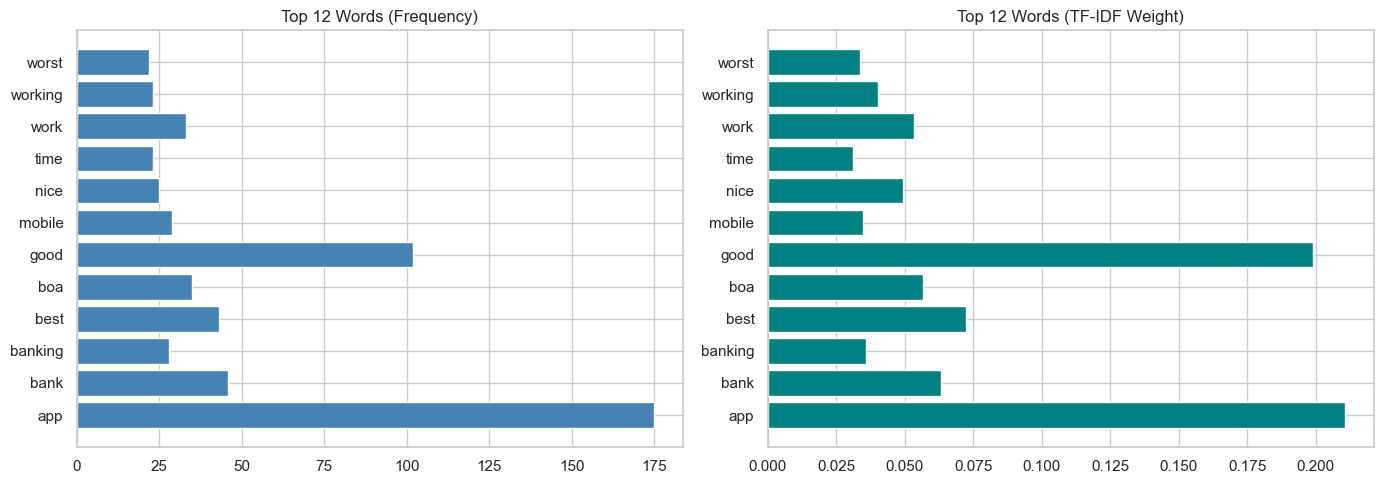

In [70]:
# Frequency (BoW) vs TF-IDF
tfidf_vec = TfidfVectorizer(max_features=12, stop_words='english')
X_tfidf = tfidf_vec.fit_transform(df_clean['clean_text'])

cv_vec = CountVectorizer(max_features=12, stop_words='english')
X_cv = cv_vec.fit_transform(df_clean['clean_text'])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].barh(cv_vec.get_feature_names_out(), X_cv.toarray().sum(axis=0), color='steelblue')
axes[0].set_title('Top 12 Words (Frequency)')

axes[1].barh(tfidf_vec.get_feature_names_out(), X_tfidf.toarray().mean(axis=0), color='teal')
axes[1].set_title('Top 12 Words (TF-IDF Weight)')

plt.tight_layout(); plt.show()

## N-gram Analysis


C:\Users\dagic\AppData\Local\Temp\ipykernel_16860\40103568.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=bi, x='count', y='ngram', ax=axes[0], palette='Greens_r')
C:\Users\dagic\AppData\Local\Temp\ipykernel_16860\40103568.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=tri, x='count', y='ngram', ax=axes[1], palette='Purples_r')


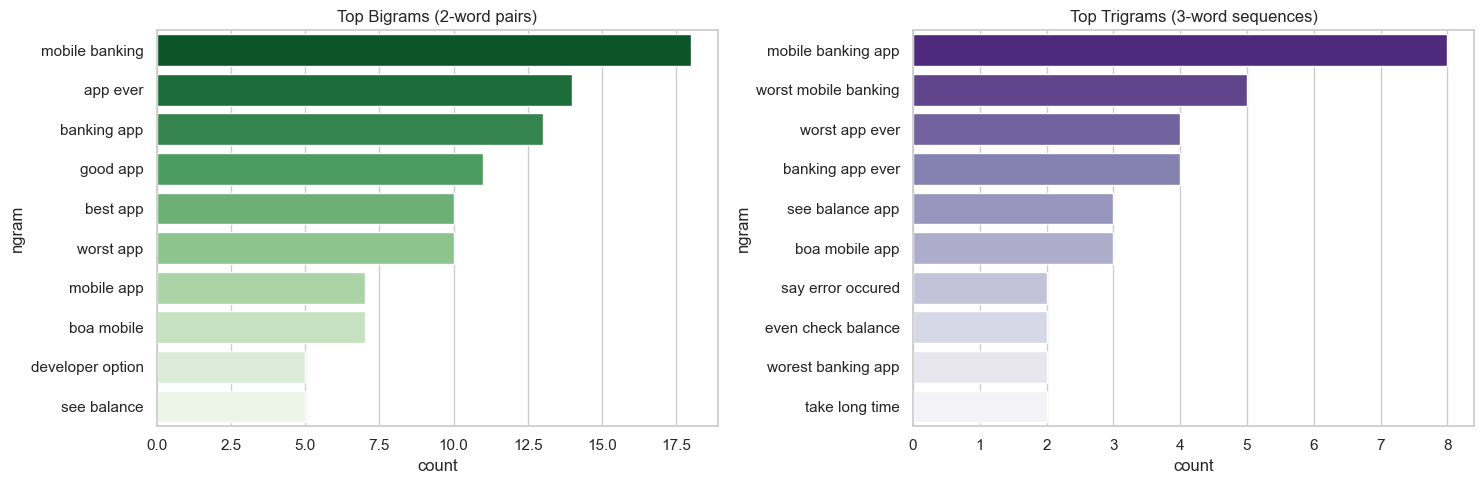

In [71]:
def get_top_ngrams(corpus, n, k=10):
    vec = CountVectorizer(ngram_range=(n,n), max_features=100)
    X = vec.fit_transform(corpus)
    counts = X.sum(axis=0).A1
    return pd.DataFrame({'ngram': vec.get_feature_names_out(), 'count': counts}).sort_values('count', ascending=False).head(k)

bi = get_top_ngrams(df_clean['clean_text'], 2)
tri = get_top_ngrams(df_clean['clean_text'], 3)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
sns.barplot(data=bi, x='count', y='ngram', ax=axes[0], palette='Greens_r')
axes[0].set_title('Top Bigrams (2-word pairs)')
sns.barplot(data=tri, x='count', y='ngram', ax=axes[1], palette='Purples_r')
axes[1].set_title('Top Trigrams (3-word sequences)')
plt.tight_layout(); plt.show()

## POS Tagging and Noun Extraction

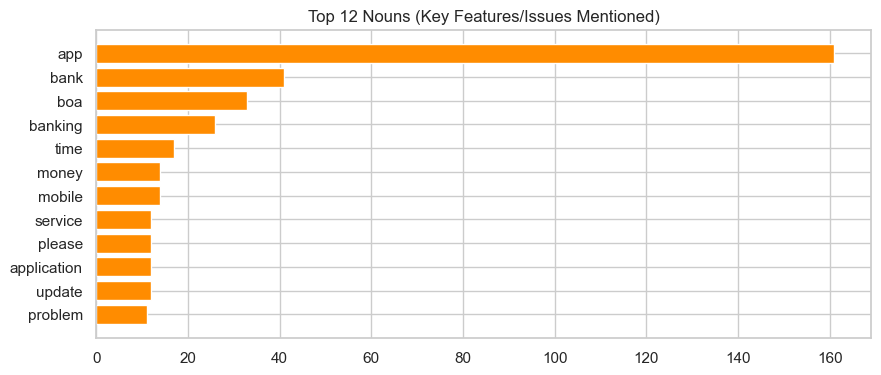

In [72]:
# Identifying Product Features (Nouns)
import nltk
from nltk import word_tokenize, pos_tag
from collections import Counter
import matplotlib.pyplot as plt

# Download the specific tagger if it's not already downloaded
try:
    nltk.data.find('taggers/averaged_perceptron_tagger_eng')
except LookupError:
    nltk.download('averaged_perceptron_tagger_eng', quiet=True)

def extract_nouns(text):
    tokens = word_tokenize(text)
    return [w.lower() for w, p in pos_tag(tokens) if p.startswith('NN') and len(w) > 2 and w.lower() not in stop_words]

df_clean['nouns'] = df_clean['review'].apply(extract_nouns)
all_nouns = [n for ns in df_clean['nouns'] for n in ns]
noun_counts = Counter(all_nouns).most_common(12)

plt.figure(figsize=(10, 4))
plt.barh([x[0] for x in noun_counts][::-1], [x[1] for x in noun_counts][::-1], color='darkorange')
plt.title('Top 12 Nouns (Key Features/Issues Mentioned)')
plt.show()

## Word Cloud

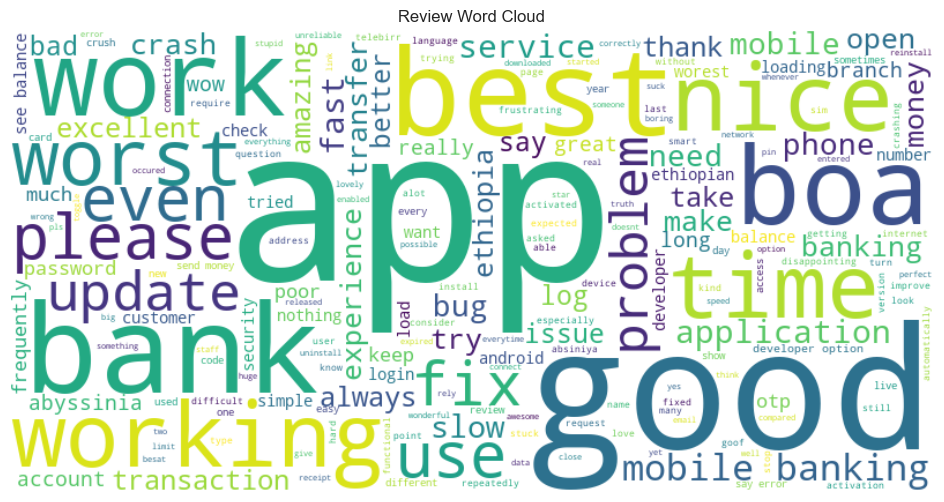

In [73]:
# Cell 8: Word Cloud
text_combined = " ".join(df_clean['clean_text'])
wc = WordCloud(width=800, height=400, background_color='white', colormap='viridis').generate(text_combined)

plt.figure(figsize=(12, 6))
plt.imshow(wc, interpolation='bilinear')
plt.axis('off')
plt.title('Review Word Cloud')
plt.show()